<a href="https://colab.research.google.com/github/nourswaid/ML-A_Z-/blob/main/Classification/random_forest/random_forest_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classification

## Importing the libraries

In [6]:
import pandas as pd
import numpy as np

## Importing the dataset

In [14]:
df=pd.read_csv('/content/Social_Network_Ads (1).csv')
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

## Splitting the dataset into the Training set and Test set

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.25)

## Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

## Training the Random Forest Classification model on the Training set

In [17]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)
classifier.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

## Predicting a new result

In [19]:
classifier.predict(sc.transform([[35,160000]]))

array([1])

## Predicting the Test set results

In [20]:
predict=classifier.predict(x_test)

## Making the Confusion Matrix

0.91

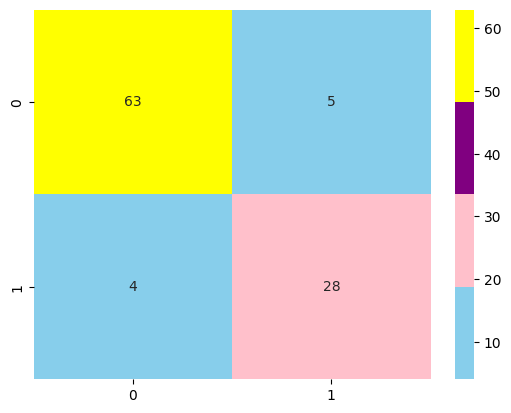

In [25]:
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
cm=confusion_matrix(y_test,predict)
sns.heatmap(cm,annot=True,cmap=['skyblue','pink','purple','yellow'])
accuracy_score(y_test,predict)


## Visualising the Test set results

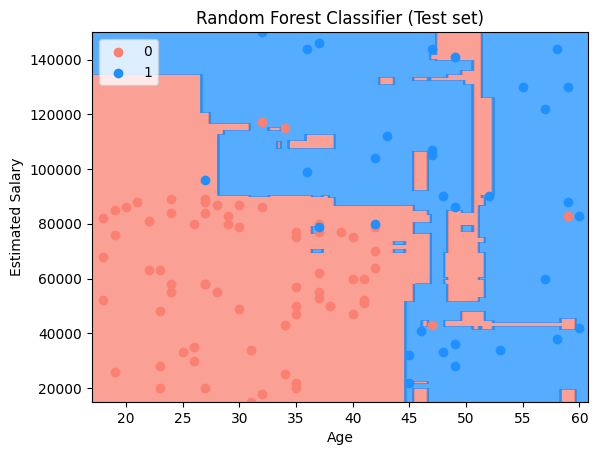

In [28]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
X_set, y_set = sc.inverse_transform(x_test), y_test
# Create a grid of points
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.25),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.25)
)
# Predict for each point on the grid
Z = classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape)
# Plot the decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap = ListedColormap(['#FA8072', '#1E90FF']) )
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
# Define colors for scatter plot
colors = ['#FA8072', '#1E90FF']
# Plot the test set points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        color=colors[i], label=j
    )
# Add titles and labels
plt.title('Random Forest Classifier (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()